In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.base import ClassifierMixin, clone

import seaborn as sns
sns.set_theme()

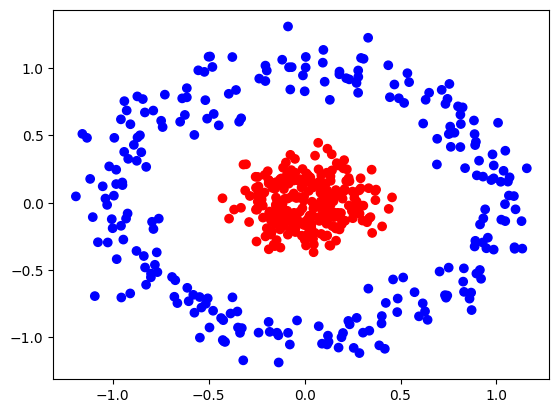

In [8]:
X, y=make_circles(n_samples=500, noise=0.1, random_state=42, factor=0.2)
y=2*y-1
X_train, X_test, y_train, y_test=train_test_split(X, y, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y+2, cmap=colors.ListedColormap(['blue', 'red']));

In [46]:
def plot_decision_boundary(model, X, y, ax=None, alpha=1, plot_points=True):
    if ax is None:
        ax=plt.axes()
    points_x=np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    points_y=np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
    mesh=np.meshgrid(points_x, points_y)
    df=pd.DataFrame(np.column_stack((mesh[0].flatten(), mesh[1].flatten())))
    
    predictions=model.predict(df)
    ax.scatter(df[0], df[1], s=2, marker='.', c=predictions+2, 
               cmap=colors.ListedColormap(['blue', 'red']), alpha=alpha)
    if plot_points:
        ax.scatter(X[:, 0], X[:, 1], c=y+2, cmap=colors.ListedColormap(['blue', 'red']))

    return ax
    


In [47]:
class AdaBoost(ClassifierMixin):
    def __init__(self, estimator, learning_rate=0.5, n_estimators=10, random_state=0):
        self.estimator=estimator # the learner that will be used
        self.learning_rate=learning_rate # the learning rate that will be used
        self.n_estimators=n_estimators # the number of max estimators to add in the ensemble
        self.actual_iterations=0 # actual iterations took to fit the model
        self.estimators=[]  # the list of trained estimators
        self.weights=[] # alphas weight of each estimator
        self.distribution=None # will contain the distribution of data points while fitting
        self.ensemble_predictions=None # will contain the ensemble training predictions (without sign operation) 
                                       # updated after adding an weak learner to the ensemble
        self.random_state=random_state

    def fit(self, X, y):
        # 1) initialize the distribution to 1/n
        # 2) make estimators=[], weights=[]

        pass